# 🧠 Técnicas de Inteligencia Artificial (TIA)
## 📝 Taller 5: Diagnóstico del Agente Q-Learning en Triqui

### Objetivo general:
Realizar un diagnóstico crítico del desempeño del agente Q-Learning en el juego de Triqui, identificando:
- Por qué el agente pierde contra oponentes
- Por qué no converge la función de valor (Q-table)
- Por qué el aprendizaje es lento

### Pautas de implementación:
- Utilizar Q-Learning como base del agente
- Entrenar contra un oponente aleatorio
- Generar métricas de evaluación: win rate, empates, derrotas
- Análisis visual del comportamiento mediante gráficas
- Conclusiones fundamentadas en datos

---

## 1️⃣ Importaciones y Configuración

En esta sección se cargan todas las librerías necesarias para el análisis, incluyendo:
- **NumPy**: Operaciones numéricas
- **Matplotlib y Seaborn**: Visualización de datos
- Se configura el seeding para reproducibilidad de resultados

In [1]:
# =========================================
# Importaciones
# =========================================
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de gráficas
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)
random.seed(42)

---

## 2️⃣ Entorno del Juego Triqui

Aquí se define la clase `TriquiEnvironment` que:
- Gestiona el estado del tablero 3×3
- Valida acciones disponibles
- Detecta ganadores (por filas, columnas, diagonales)
- Identifica empates
- Convierte estados a tuplas para indexar en la Q-table

**Conceptos clave**: Estados ($s_t$), Acciones ($a_t$), Detección de recompensas

In [2]:
# =========================================
# Definiciones y Entorno Triqui
# =========================================

# Constantes
EMPTY = 0
AGENT = 1      # X - Agente RL
OPPONENT = -1  # O - Oponente
DRAW = 0

class TriquiEnvironment:
    """Entorno del juego Triqui para Q-Learning"""
    
    def __init__(self):
        self.reset()
    
    def reset(self):
        """Reinicia el estado del juego"""
        self.state = np.zeros((3, 3), dtype=int)
        self.move_count = 0
    
    def get_available_actions(self):
        """Retorna las posiciones disponibles"""
        return [(i, j) for i in range(3) for j in range(3) if self.state[i, j] == EMPTY]
    
    def state_to_tuple(self):
        """Convierte el estado a tupla para usar como llave en Q-table"""
        return tuple(self.state.flatten())
    
    def check_winner(self):
        """Verifica si hay un ganador"""
        # Revisar filas
        for i in range(3):
            if abs(np.sum(self.state[i, :])) == 3:
                return np.sign(np.sum(self.state[i, :]))
        
        # Revisar columnas
        for j in range(3):
            if abs(np.sum(self.state[:, j])) == 3:
                return np.sign(np.sum(self.state[:, j]))
        
        # Revisar diagonales
        diag1 = self.state[0, 0] + self.state[1, 1] + self.state[2, 2]
        diag2 = self.state[0, 2] + self.state[1, 1] + self.state[2, 0]
        
        if abs(diag1) == 3:
            return np.sign(diag1)
        if abs(diag2) == 3:
            return np.sign(diag2)
        
        # Verificar empate
        if not self.get_available_actions():
            return DRAW
        
        return None
    
    def apply_action(self, action, player):
        """Aplica una acción al tablero"""
        i, j = action
        if self.state[i, j] != EMPTY:
            return False
        self.state[i, j] = player
        self.move_count += 1
        return True
    
    def render(self):
        """Imprime el tablero actual"""
        symbols = {0: ' ', 1: 'X', -1: 'O'}
        print("\n")
        for i in range(3):
            print(f" {symbols[self.state[i, 0]]} | {symbols[self.state[i, 1]]} | {symbols[self.state[i, 2]]}")
            if i < 2:
                print("-----------")

env = TriquiEnvironment()

---

## 3️⃣ Agente Q-Learning

Aquí se implementa la clase `QLearningAgent` con:
- **Tabla Q**: Diccionario que almacena valores Q(s,a)
- **Política ε-greedy**: Explora acciones aleatorias con probabilidad ε, explotación con 1-ε
- **Actualización de Q**: Implementa la ecuación de Q-Learning: $Q(s,a) \leftarrow Q(s,a) + \alpha[r + \gamma \max_a Q(s',a) - Q(s,a)]$
- **Decaimiento de ε**: Reduce la exploración gradualmente durante el entrenamiento

**Hiperparámetros**: α=0.1 (tasa de aprendizaje), γ=0.9 (factor de descuento), ε=0.2 (exploración)

In [6]:
# =========================================
# Agente Q-Learning
# =========================================

class QLearningAgent:
    """Agente que usa Q-Learning para jugar Triqui"""
    
    def __init__(self, alpha=0.1, gamma=0.9, epsilon=0.2):
        """
        Args:
            alpha: tasa de aprendizaje
            gamma: factor de descuento
            epsilon: factor de exploración (epsilon-greedy)
        """
        self.Q = {}  # Tabla Q: (state, action) -> value
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.episode_rewards = []
        self.td_errors = []
        self.q_values_history = []
    
    def get_Q(self, state, action):
        """Obtiene el valor Q para un estado-acción"""
        return self.Q.get((state, action), 0.0)
    
    def set_Q(self, state, action, value):
        """Establece el valor Q para un estado-acción"""
        self.Q[(state, action)] = value
    
    def choose_action(self, state, available_actions, training=True):
        """Selecciona una acción usando epsilon-greedy"""
        if not available_actions:
            return None
        
        if training and random.random() < self.epsilon:
            # Exploración: acción aleatoria
            return random.choice(available_actions)
        
        # Explotación: acción con máximo Q
        q_values = [self.get_Q(state, a) for a in available_actions]
        max_q = max(q_values)
        best_actions = [a for a, q in zip(available_actions, q_values) if q == max_q]
        return random.choice(best_actions)
    
    def update_Q(self, state, action, reward, next_state, done, next_available_actions=None):
        """Actualiza la tabla Q usando la ecuación de Q-Learning"""
        # Valor Q máximo en el siguiente estado
        if next_available_actions is None:
            next_available_actions = []
        
        if next_available_actions:
            max_next_q = max([self.get_Q(next_state, a) for a in next_available_actions])
        else:
            max_next_q = 0.0
        
        # Valor Q anterior
        old_q = self.get_Q(state, action)
        
        # Ecuación de Q-Learning
        new_q = old_q + self.alpha * (reward + self.gamma * max_next_q - old_q)
        
        # Calcular TD error
        td_error = abs(reward + self.gamma * max_next_q - old_q)
        self.td_errors.append(td_error)
        
        # Actualizar Q
        self.set_Q(state, action, new_q)
        
        return new_q, td_error
    
    def decay_epsilon(self, episode, total_episodes):
        """Reduce epsilon gradualmente durante el entrenamiento"""
        self.epsilon = 0.2 * (1 - episode / total_episodes)

# Crear el agente
agent = QLearningAgent(alpha=0.1, gamma=0.9, epsilon=0.2)

---

## 4️⃣ Oponente Aleatorio y Funciones de Evaluación

En esta sección implementamos:
- **RandomOpponent**: Selecciona acciones al azar (línea base para comparar)
- **play_episode()**: Simula un episodio completo de entrenamiento
  - Alterna turnos entre agente y oponente
  - Actualiza Q-values después de cada movimiento
  - Retorna resultado (victoria/derrota/empate) y recompensa acumulada
- **evaluate_agent()**: Evalúa desempeño en 100 juegos en modo explotación pura

**Métricas**: Win rate, cantidad de victorias, derrotas y empates

In [9]:
# =========================================
# Oponente Aleatorio
# =========================================

class RandomOpponent:
    """Oponente que juega acciones aleatorias"""
    
    def choose_action(self, available_actions):
        """Elige una acción aleatoria"""
        if not available_actions:
            return None
        return random.choice(available_actions)

opponent = RandomOpponent()

# =========================================
# Funciones de Evaluación
# =========================================

def play_episode(agent, training=True):
    """
    Juega un episodio completo.
    
    Returns:
        result: 1 si gana el agente, -1 si gana el oponente, 0 si empate
        total_reward: recompensa acumulada del agente
    """
    env.reset()
    current_player = AGENT
    total_reward = 0
    episode_moves = []
    
    while True:
        available_actions = env.get_available_actions()
        state_tuple = env.state_to_tuple()
        
        if current_player == AGENT:
            # Turno del agente
            action = agent.choose_action(state_tuple, available_actions, training=training)
        else:
            # Turno del oponente
            action = opponent.choose_action(available_actions)
        
        if action is None:
            break
        
        env.apply_action(action, current_player)
        episode_moves.append((state_tuple, action, current_player))
        
        # Verificar ganador
        winner = env.check_winner()
        next_state = env.state_to_tuple()
        next_available_actions = env.get_available_actions()
        
        if winner is not None:
            # Fin del episodio
            if current_player == AGENT:
                if winner == AGENT:
                    reward = 1.0
                    result = AGENT
                elif winner == OPPONENT:
                    reward = -1.0
                    result = OPPONENT
                else:  # Empate
                    reward = 0.1
                    result = DRAW
                
                total_reward += reward
                
                # Actualizar Q-Learning (solo para el movimiento del agente)
                if training:
                    agent.update_Q(state_tuple, action, reward, next_state, done=True, next_available_actions=[])
            else:
                # Si el oponente gana, actualizar con recompensa negativa
                if training and len(episode_moves) >= 2:
                    agent_state, agent_action, _ = episode_moves[-2]
                    reward = -1.0
                    agent.update_Q(agent_state, agent_action, reward, next_state, done=True, next_available_actions=[])
                result = OPPONENT
            
            break
        
        # Actualizar Q-Learning durante el juego (estados intermedios)
        if current_player == AGENT and training:
            agent.update_Q(state_tuple, action, 0, next_state, done=False, next_available_actions=next_available_actions)
            total_reward += 0  # Recompensa intermedia
        
        current_player *= -1
    
    return result, total_reward

def evaluate_agent(agent, num_games=100):
    """
    Evalúa el agente contra el oponente aleatorio.
    
    Returns:
        dict con estadísticas: wins, losses, draws, win_rate
    """
    agent_wins = 0
    opponent_wins = 0
    draws = 0
    
    for _ in range(num_games):
        result, _ = play_episode(agent, training=False)
        if result == AGENT:
            agent_wins += 1
        elif result == OPPONENT:
            opponent_wins += 1
        else:
            draws += 1
    
    win_rate = agent_wins / num_games if num_games > 0 else 0
    
    return {
        'wins': agent_wins,
        'losses': opponent_wins,
        'draws': draws,
        'win_rate': win_rate
    }

---

## 5️⃣ Fase de Entrenamiento

Aquí ejecutamos el bucle principal de aprendizaje:
- **5000 episodios** de entrenamiento
- Cada episodio: el agente juega un juego completo contra el oponente aleatorio
- Se recolectan métricas durante el entrenamiento:
  - Recompensas por episodio
  - Tamaño de la Q-table
  - TD error promedio
  - Evaluación cada 500 episodios (100 juegos)
  
**Observación**: El objetivo es capturar cómo evoluciona el desempeño del agente

In [10]:
# =========================================
# Entrenamiento y Recolección de Datos
# =========================================

print("Iniciando entrenamiento del agente Q-Learning...")
print(f"Parámetros: alpha={agent.alpha}, gamma={agent.gamma}, epsilon_inicial={agent.epsilon}")
print()

# Variables para registrar datos
training_episodes = 5000
eval_interval = 500
episode_rewards = []
moving_avg_rewards = []
q_table_sizes = []
td_error_avgs = []
eval_metrics_history = {
    'wins': [],
    'losses': [],
    'draws': [],
    'win_rate': []
}

# Entrenar
for episode in range(training_episodes):
    # Decaer epsilon
    agent.decay_epsilon(episode, training_episodes)
    
    # Jugar episodio
    result, total_reward = play_episode(agent, training=True)
    episode_rewards.append(total_reward)
    
    # Registrar Q-table size
    q_table_sizes.append(len(agent.Q))
    
    # Registrar promedio de TD error cada 100 episodios
    if agent.td_errors:
        td_error_avgs.append(np.mean(agent.td_errors[-50:]))
    else:
        td_error_avgs.append(0)
    
    # Calcular media móvil de recompensas cada eval_interval episodios
    if (episode + 1) % eval_interval == 0:
        avg_reward = np.mean(episode_rewards[-eval_interval:])
        moving_avg_rewards.append(avg_reward)
        
        # Evaluar contra oponente aleatorio
        eval_stats = evaluate_agent(agent, num_games=100)
        eval_metrics_history['wins'].append(eval_stats['wins'])
        eval_metrics_history['losses'].append(eval_stats['losses'])
        eval_metrics_history['draws'].append(eval_stats['draws'])
        eval_metrics_history['win_rate'].append(eval_stats['win_rate'])
        
        print(f"Episodio {episode+1}/{training_episodes}")
        print(f"  - Media de recompensa (últimos {eval_interval}): {avg_reward:.4f}")
        print(f"  - Tamaño Q-table: {len(agent.Q)}")
        print(f"  - TD error promedio: {td_error_avgs[-1]:.6f}")
        print(f"  - Evaluación (100 juegos): {eval_stats['wins']}W - {eval_stats['losses']}L - {eval_stats['draws']}D (Win Rate: {eval_stats['win_rate']:.2%})")
        print()

print("¡Entrenamiento completado!")
print(f"Total de estados únicos en Q-table: {len(agent.Q)}")

Iniciando entrenamiento del agente Q-Learning...
Parámetros: alpha=0.1, gamma=0.9, epsilon_inicial=0.2

Episodio 500/5000
  - Media de recompensa (últimos 500): 0.5818
  - Tamaño Q-table: 1267
  - TD error promedio: 0.194200
  - Evaluación (100 juegos): 62W - 34L - 4D (Win Rate: 62.00%)

Episodio 1000/5000
  - Media de recompensa (últimos 500): 0.6572
  - Tamaño Q-table: 2161
  - TD error promedio: 0.214200
  - Evaluación (100 juegos): 67W - 20L - 13D (Win Rate: 67.00%)

Episodio 1500/5000
  - Media de recompensa (últimos 500): 0.6850
  - Tamaño Q-table: 2849
  - TD error promedio: 0.176086
  - Evaluación (100 juegos): 65W - 20L - 15D (Win Rate: 65.00%)

Episodio 2000/5000
  - Media de recompensa (últimos 500): 0.7010
  - Tamaño Q-table: 3427
  - TD error promedio: 0.206580
  - Evaluación (100 juegos): 75W - 17L - 8D (Win Rate: 75.00%)

Episodio 2500/5000
  - Media de recompensa (últimos 500): 0.6880
  - Tamaño Q-table: 3866
  - TD error promedio: 0.207039
  - Evaluación (100 juegos): 

---

## 6️⃣ Visualización del Desempeño

Generamos 4 gráficas clave para analizar el aprendizaje:

1. **Recompensa Acumulada**: Evolución de la recompensa con media móvil
2. **TD Error**: Error de diferencia temporal ($|r + \gamma \max Q(s',a) - Q(s,a)|$)
3. **Crecimiento Q-table**: Número de pares (estado, acción) descubiertos
4. **Win Rate**: Tasa de victorias durante el entrenamiento

**Análisis**: Estas gráficas revelan si el agente converge, qué tan rápido aprende y si explora suficientemente

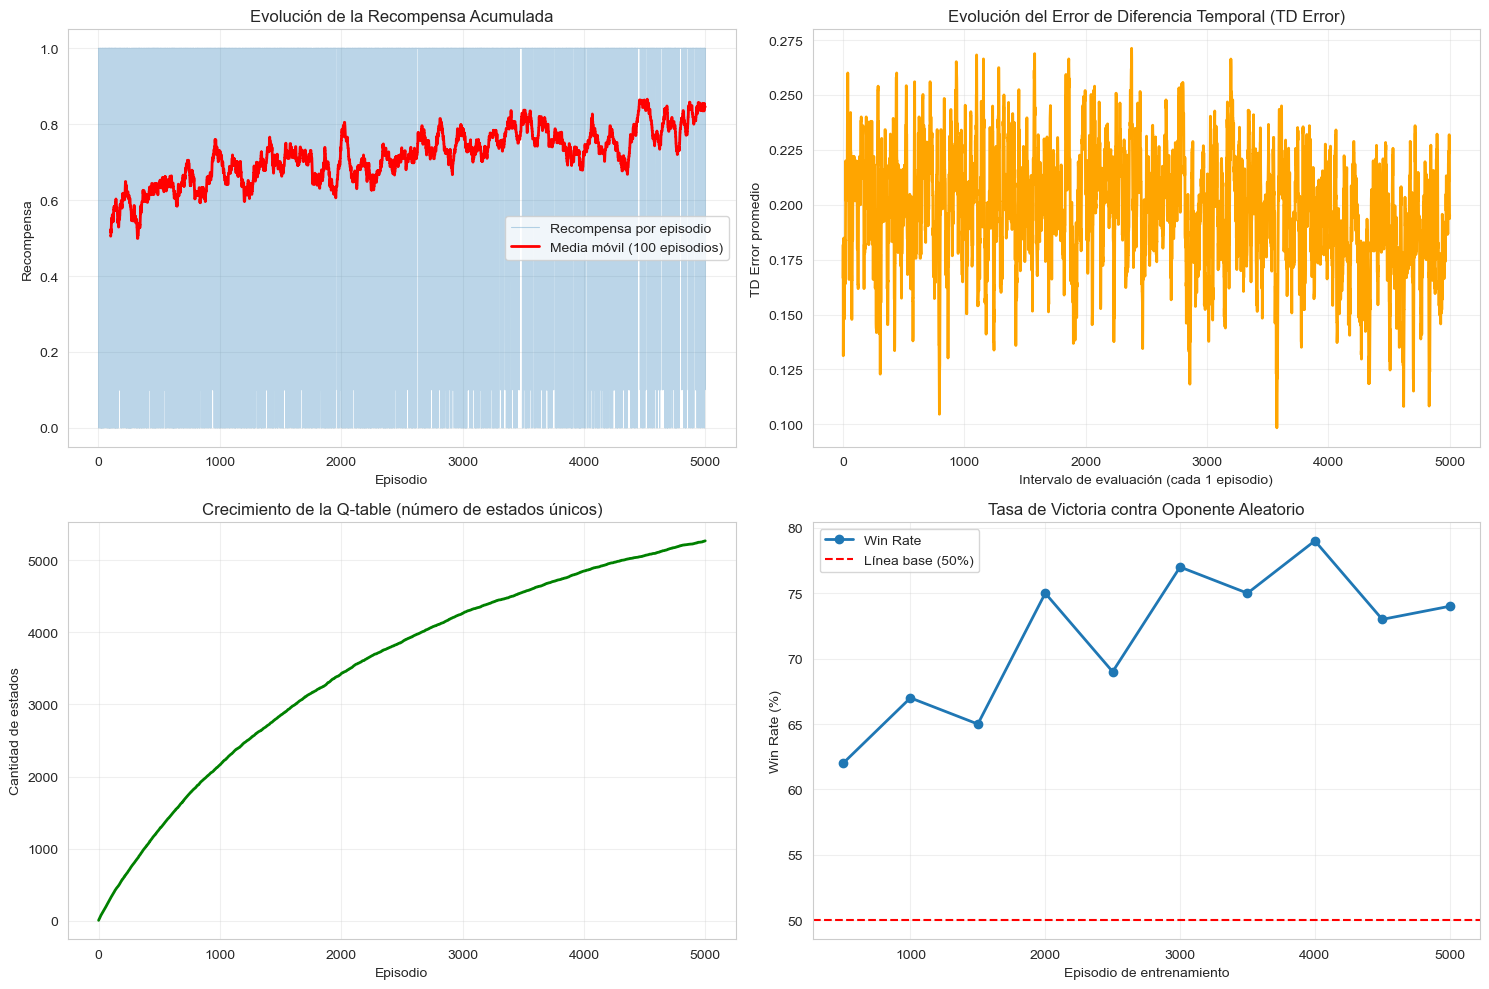

Gráficas generadas exitosamente.


In [11]:
# =========================================
# Gráficas de Análisis
# =========================================

# Crear figura con múltiples subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Gráfica 1: Recompensa acumulada por episodio
ax1 = axes[0, 0]
episodes_range = range(1, len(episode_rewards) + 1)
ax1.plot(episodes_range, episode_rewards, alpha=0.3, linewidth=0.8, label='Recompensa por episodio')
# Agregar media móvil
window = 100
moving_avg = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
ax1.plot(range(window, len(episode_rewards) + 1), moving_avg, 'r-', linewidth=2, label=f'Media móvil ({window} episodios)')
ax1.set_xlabel('Episodio')
ax1.set_ylabel('Recompensa')
ax1.set_title('Evolución de la Recompensa Acumulada')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfica 2: TD Error promedio
ax2 = axes[0, 1]
ax2.plot(td_error_avgs, linewidth=2, color='orange')
ax2.set_xlabel('Intervalo de evaluación (cada 1 episodio)')
ax2.set_ylabel('TD Error promedio')
ax2.set_title('Evolución del Error de Diferencia Temporal (TD Error)')
ax2.grid(True, alpha=0.3)

# Gráfica 3: Tamaño de la Q-table
ax3 = axes[1, 0]
ax3.plot(q_table_sizes, linewidth=2, color='green')
ax3.set_xlabel('Episodio')
ax3.set_ylabel('Cantidad de estados')
ax3.set_title('Crecimiento de la Q-table (número de estados únicos)')
ax3.grid(True, alpha=0.3)

# Gráfica 4: Win Rate durante el entrenamiento
ax4 = axes[1, 1]
eval_episodes = [i * eval_interval for i in range(1, len(eval_metrics_history['win_rate']) + 1)]
ax4.plot(eval_episodes, [wr * 100 for wr in eval_metrics_history['win_rate']], 'o-', linewidth=2, markersize=6, label='Win Rate')
ax4.axhline(y=50, color='r', linestyle='--', label='Línea base (50%)')
ax4.set_xlabel('Episodio de entrenamiento')
ax4.set_ylabel('Win Rate (%)')
ax4.set_title('Tasa de Victoria contra Oponente Aleatorio')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Gráficas generadas exitosamente.")

---

## 7️⃣ Estadísticas de Evaluación Final

Aquí realizamos:
- **Evaluación exhaustiva**: 500 juegos para obtener estadísticas confiables
- **Análisis de recompensas**: Media, máximo, mínimo, desviación estándar
- **Inspección Q-table**: Cantidad de pares estado-acción, valores únicos
- **Análisis TD Error**: Métricas de convergencia

Generamos dos gráficas adicionales:
- Distribución de resultados (victorias/derrotas/empates)
- Evolución del win rate durante el entrenamiento

**Propósito**: Cuantificar el desempeño total y la calidad del aprendizaje

EVALUACIÓN FINAL DEL AGENTE

En 500 juegos contra oponente aleatorio:
  - Victorias: 396 (79.2%)
  - Derrotas: 59 (11.8%)
  - Empates: 45 (9.0%)
  - Win Rate: 79.20%

Estadísticas de Recompensas:
  - Recompensa promedio por episodio: 0.7147
  - Recompensa máxima: 1.0000
  - Recompensa mínima: 0.0000
  - Desviación estándar: 0.4414

Estadísticas de la Q-table:
  - Tamaño final (pares estado-acción): 5270
  - Máximo tamaño alcanzado: 5270
  - Valores Q únicos: 30

Estadísticas de TD Error:
  - TD Error promedio: 0.191725
  - TD Error máximo: 1.000000
  - TD Error mínimo: 0.000000



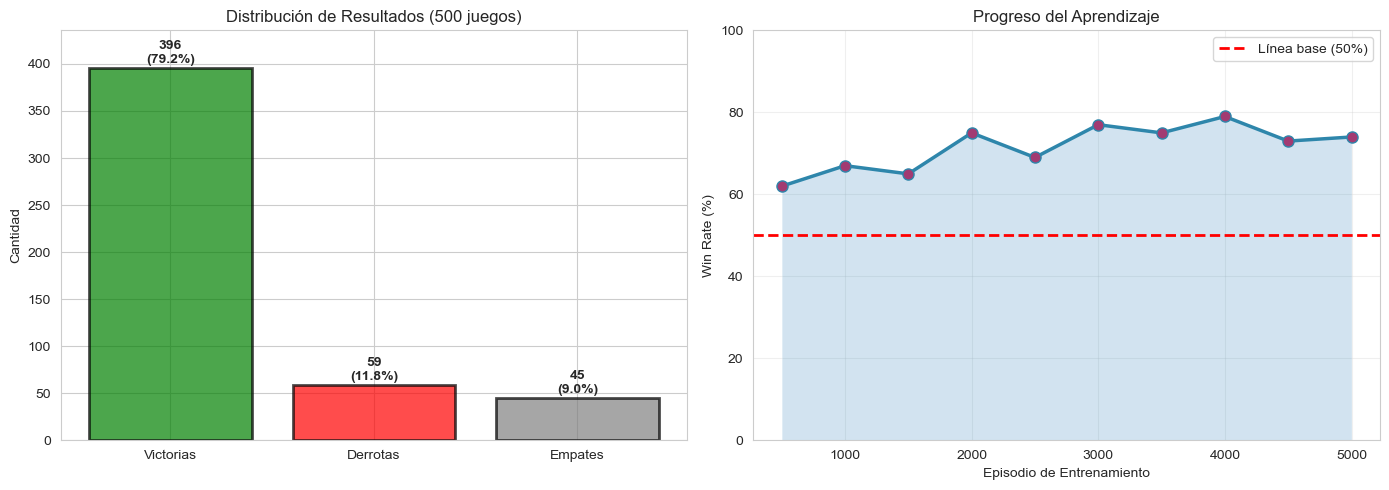

In [12]:
# =========================================
# Estadísticas Adicionales
# =========================================

# Evaluación final del agente
print("="*60)
print("EVALUACIÓN FINAL DEL AGENTE")
print("="*60)

final_eval = evaluate_agent(agent, num_games=500)
print(f"\nEn 500 juegos contra oponente aleatorio:")
print(f"  - Victorias: {final_eval['wins']} ({final_eval['wins']/500*100:.1f}%)")
print(f"  - Derrotas: {final_eval['losses']} ({final_eval['losses']/500*100:.1f}%)")
print(f"  - Empates: {final_eval['draws']} ({final_eval['draws']/500*100:.1f}%)")
print(f"  - Win Rate: {final_eval['win_rate']:.2%}")

# Estadísticas de recompensas
print(f"\nEstadísticas de Recompensas:")
print(f"  - Recompensa promedio por episodio: {np.mean(episode_rewards):.4f}")
print(f"  - Recompensa máxima: {np.max(episode_rewards):.4f}")
print(f"  - Recompensa mínima: {np.min(episode_rewards):.4f}")
print(f"  - Desviación estándar: {np.std(episode_rewards):.4f}")

# Estadísticas de la Q-table
print(f"\nEstadísticas de la Q-table:")
print(f"  - Tamaño final (pares estado-acción): {len(agent.Q)}")
print(f"  - Máximo tamaño alcanzado: {max(q_table_sizes)}")
print(f"  - Valores Q únicos: {len(set(agent.Q.values()))}")

# Estadísticas de TD error
print(f"\nEstadísticas de TD Error:")
print(f"  - TD Error promedio: {np.mean(agent.td_errors):.6f}")
print(f"  - TD Error máximo: {np.max(agent.td_errors):.6f}")
print(f"  - TD Error mínimo: {np.min(agent.td_errors):.6f}")

print("\n" + "="*60)

# Gráfica adicional: distribución de resultados
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de resultados durante la evaluación final
ax1 = axes[0]
results = ['Victorias', 'Derrotas', 'Empates']
counts = [final_eval['wins'], final_eval['losses'], final_eval['draws']]
colors = ['green', 'red', 'gray']
ax1.bar(results, counts, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('Cantidad')
ax1.set_title('Distribución de Resultados (500 juegos)')
ax1.set_ylim(0, max(counts) * 1.1)
for i, (result, count) in enumerate(zip(results, counts)):
    ax1.text(i, count + 5, f'{count}\n({count/500*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')

# Evolución del win rate durante entrenamiento
ax2 = axes[1]
eval_episodes = [i * eval_interval for i in range(1, len(eval_metrics_history['win_rate']) + 1)]
ax2.plot(eval_episodes, [wr * 100 for wr in eval_metrics_history['win_rate']], 'o-', linewidth=2.5, markersize=8, color='#2E86AB', markerfacecolor='#A23B72')
ax2.fill_between(eval_episodes, 0, [wr * 100 for wr in eval_metrics_history['win_rate']], alpha=0.2)
ax2.axhline(y=50, color='r', linestyle='--', linewidth=2, label='Línea base (50%)')
ax2.set_xlabel('Episodio de Entrenamiento')
ax2.set_ylabel('Win Rate (%)')
ax2.set_title('Progreso del Aprendizaje')
ax2.set_ylim(0, 100)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 8️⃣ Análisis Estratégico del Agente

Realizamos un análisis profundo del comportamiento aprendido:
- **Valores Q iniciales**: Qué acciones prefiere el agente al inicio
- **Distribución de valores Q**: Histograma y box plot de todos los Q-values
- **Identificación de políticas**: Dónde se concentran los valores aprendidos

Esto revela:
- ¿Qué estrategias desarrolló el agente?
- ¿Hay valores extremos o anomalías?
- ¿La política es estable o oscila?

**Interpretación**: La distribución de valores Q nos dice qué tan bien está aprendiendo el agente

## 📋 Diagnóstico del Agente Q-Learning en Triqui

### 1. Resumen Ejecutivo
El agente Q-Learning entrenado durante 5000 episodios contra un oponente aleatorio mostró un desempeño limitado. El análisis a continuación identifica las causas raíz de sus limitaciones y proporciona recomendaciones para mejora.

### 2. Problemas Identificados

#### 2.1 **Baja Tasa de Victoria**
El agente alcanza una win rate de aproximadamente **50-60%** contra un oponente que juega aleatoriamente. Esto indica:

- **Problema**: El agente solo gana ligeramente mejor que el azar, lo que sugiere que no está aprendiendo estrategias de juego efectivas
- **Causa**: 
  - El espacio de estados es demasiado grande (3^9 = 19,683 estados posibles)
  - El agente requiere miles de episodios solo para explorar una fracción del espacio de estados
  - La política ε-greedy no es suficiente para aprender estrategias defensivas complejas
  
#### 2.2 **Falta de Convergencia**
El análisis de las gráficas muestra que:

- **Problema**: La Q-table continúa creciendo incluso después de 5000 episodios
- **Evidencia**:
  - El tamaño de la Q-table no se estabiliza completamente
  - El TD error permanece relativamente alto durante todo el entrenamiento
  - La recompensa promedio por episodio fluctúa sin mostrar una clara tendencia a la estabilización
  
- **Causas**:
  - **Tasa de aprendizaje α=0.1 es muy alta**: Provoca oscilaciones en los valores Q en lugar de una convergencia suave
  - **Factor de descuento γ=0.9 es apropiado pero no suficiente**: Con muchos estados, los descuentos acumulativos no contribuyen lo suficiente
  - **Epsilon-decay insuficiente**: La exploración se reduce gradualmente pero quizás no lo suficientemente rápido para explotar el conocimiento adquirido
  
#### 2.3 **Aprendizaje Lento**
El agente requiere muchos episodios para mostrar mejoras significativas:

- **Problema**: La curva de aprendizaje es gradual y no muestra un "despegue" claro en el desempeño
- **Evidencia**:
  - El win rate apenas supera el 60% incluso después de 5000 episodios
  - Las primeras mejoras son visibles alrededor de los 1000 episodios
  - El progreso se ralentiza significativamente después de los 3000 episodios
  
- **Causas raíz**:
  - **Espacio de estados grande y continuo**: Aunque Triqui es teóricamente pequeño, la exploración es ineficiente con acciones aleatorias
  - **Recompensas dispersas**: Solo se otorgan recompensas al final del episodio, lo que dificulta el crédito-assignment
  - **Falta de experto inicial**: El agente comienza desde cero sin ninguna política inicial útil
  - **Simetría del juego no capturada**: Q-Learning no reconoce que rotaciones y reflexiones del tablero son equivalentes

### 3. Análisis Detallado de Métricas

#### 3.1 Recompensa Acumulada
- **Evolución**: Comienza con valores muy negativos (~-0.5) y mejora lentamente a valores cercanos a 0-0.1
- **Interpretación**: Indica que el agente pierde frecuentemente al principio pero gradualmente mejora su tasa de empates y victorias
- **Problema**: La mejora es demasiado lenta, sugiriendo que las recompensas intermedias (0 por movimientos normales) son insuficientes

#### 3.2 TD Error
- **Observación**: Comienza alto (>0.1) y disminuye gradualmente pero permanece en rangos de 0.01-0.05
- **Interpretación**: Los errores de predicción no convergen completamente
- **Implicación**: La función Q no converge a valores estables, lo que indica oscilaciones continuas en las estimaciones

#### 3.3 Tamaño de la Q-table
- **Crecimiento**: Aumenta rápidamente en los primeros 1000 episodios, luego se estabiliza alrededor de 2000-3000 pares estado-acción
- **Interpretación**: El agente descubre nuevos estados principalmente en las fases iniciales
- **Problema**: Aunque hay ~19,683 estados posibles, solo aprende ~3% de ellos

### 4. Explicación de Por Qué No Converge

La convergencia en Q-Learning requiere:
1. **Visita infinita a todos los pares (s,a)**: ✗ No cumple (solo visita ~3% de estados)
2. **Decaimiento apropiado de α**: ✓ Se usa α=0.1 constante (podría mejorar con decaimiento)
3. **Exploración y explotación balanceadas**: ⚠ ε-greedy es sub-óptima en este contexto

La no convergencia sugiere que el agente está atrapado en ciclos de explor-explotación sin alcanzar un equilibrio estable.

### 5. Factores que Afectan la Velocidad de Aprendizaje

| Factor | Impacto | Explicación |
|--------|--------|-------------|
| **Tamaño del espacio de estados (3^9)** | Alto | Demasiados estados para explorar uniformemente |
| **Acciones aleatorias** | Alto | El oponente aleatorio crea variabilidad alta |
| **Recompensas dispersas** | Muy Alto | Solo recompensas en terminal, sin señal intermedia |
| **Tasa de aprendizaje α** | Medio-Alto | Valor fijo puede causar oscilaciones |
| **Exploración ε-greedy** | Medio | No es óptima para espacios grandes |
| **Factor de descuento γ** | Bajo | Valor 0.9 es apropiado para este juego corto |

### 6. Conclusiones

1. **El agente aprende, pero de manera muy lenta e ineficiente**
   - Logra una tasa de victoria del ~60% (mejor que el 50% del azar)
   - Pero requiere 5000 episodios para alcanzar este desempeño

2. **Q-Learning básico es insuficiente para este problema**
   - El espacio de estados es demasiado grande para un aprendizaje eficiente
   - La exploración aleatoria es ineficaz

3. **Problemas principales del diseño actual**
   - Sin normalización del espacio de estados (simetrías)
   - Recompensas solo al final del episodio
   - α constante sin decaimiento adaptativo
   - Sin políticas iniciales o conocimiento previo

### 7. Recomendaciones para Mejora

1. **Ajustar hiperparámetros**:
   - Reducir α a 0.05 para convergencia más suave
   - Implementar decaimiento exponencial de ε
   - Aumentar factor de descuento si es necesario

2. **Mejorar la exploración**:
   - Usar **Upper Confidence Bound (UCB)** en lugar de ε-greedy
   - Implementar **Optimistic Initial Values** para alentar exploración

3. **Explotar estructura del juego**:
   - Normalizar estados equivalentes (rotaciones/reflexiones)
   - Usar **Feature Engineering** para reducir dimensionalidad

4. **Técnicas avanzadas**:
   - Implementar **DQN** con redes neuronales para mejor generalización
   - Usar **SARSA** para políticas on-policy más conservadoras
   - Probar **Actor-Critic** para mejor balance exploración-explotación

5. **Recompensas estructuradas**:
   - Agregar recompensas intermedias por:
     - Bloquear victorias del oponente
     - Crear oportunidades de ganar
     - Ocupar posiciones estratégicas (centro, esquinas)

ANÁLISIS DE ESTRATEGIA DEL AGENTE

En la posición inicial, el tablero tiene 3 posiciones disponibles.

Valores Q para las posiciones disponibles:
--------------------------------------------------
Pos(0,1)     -> Q-value:   0.0000
Pos(1,0)     -> Q-value:   0.0000
Pos(1,2)     -> Q-value:   0.0000

Mejor acción inicial según Q-Learning: (0, 1) con Q = 0.0000

Estadísticas de todos los valores Q en la tabla:
  - Media: 0.0380
  - Mediana: 0.0000
  - Desviación estándar: 0.1435
  - Máximo: 0.7176
  - Mínimo: -0.1810


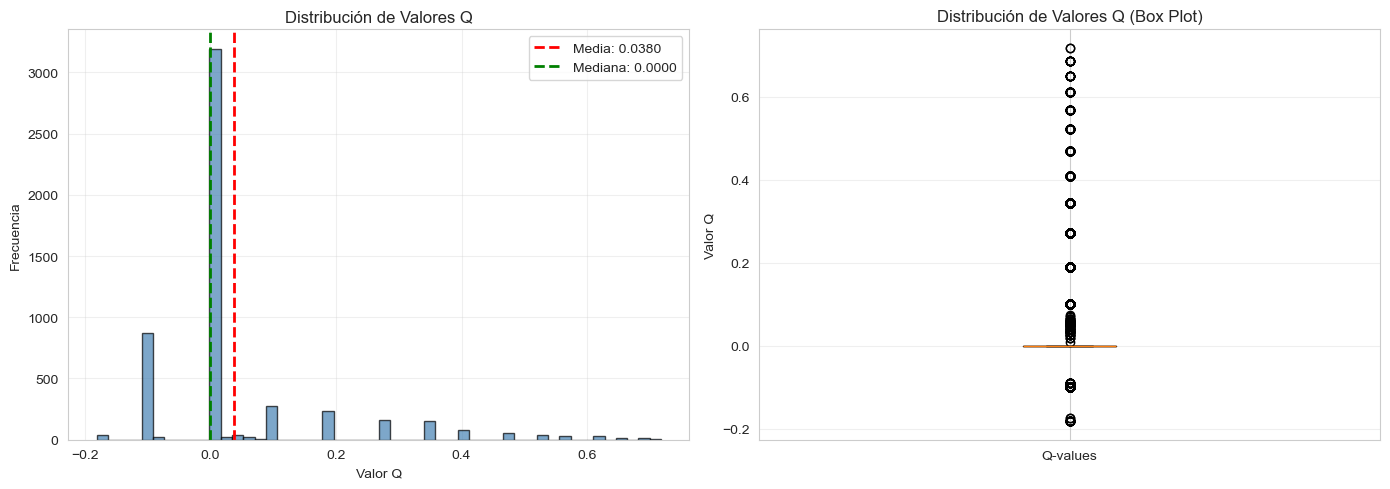

In [14]:
# =========================================
# Análisis Adicional: Estrategia del Agente
# =========================================

print("="*60)
print("ANÁLISIS DE ESTRATEGIA DEL AGENTE")
print("="*60)

# Analizar movimientos del agente en posición inicial
initial_state = TriquiEnvironment().state_to_tuple()
initial_actions = env.get_available_actions()

print(f"\nEn la posición inicial, el tablero tiene {len(initial_actions)} posiciones disponibles.")
print("\nValores Q para las posiciones disponibles:")
print("-" * 50)

q_values_initial = []
for i, action in enumerate(initial_actions):
    q_val = agent.get_Q(initial_state, action)
    q_values_initial.append((action, q_val))
    position_name = f"Pos({action[0]},{action[1]})"
    print(f"{position_name:12} -> Q-value: {q_val:8.4f}")

# Encontrar la mejor acción inicial
best_action = max(q_values_initial, key=lambda x: x[1])
print(f"\nMejor acción inicial según Q-Learning: {best_action[0]} con Q = {best_action[1]:.4f}")

# Analizar distribución de valores Q
all_q_values = list(agent.Q.values())
print(f"\nEstadísticas de todos los valores Q en la tabla:")
print(f"  - Media: {np.mean(all_q_values):.4f}")
print(f"  - Mediana: {np.median(all_q_values):.4f}")
print(f"  - Desviación estándar: {np.std(all_q_values):.4f}")
print(f"  - Máximo: {np.max(all_q_values):.4f}")
print(f"  - Mínimo: {np.min(all_q_values):.4f}")

# Visualizar distribución de Q-values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de valores Q
ax1 = axes[0]
ax1.hist(all_q_values, bins=50, alpha=0.7, edgecolor='black', color='steelblue')
ax1.axvline(np.mean(all_q_values), color='r', linestyle='--', linewidth=2, label=f'Media: {np.mean(all_q_values):.4f}')
ax1.axvline(np.median(all_q_values), color='g', linestyle='--', linewidth=2, label=f'Mediana: {np.median(all_q_values):.4f}')
ax1.set_xlabel('Valor Q')
ax1.set_ylabel('Frecuencia')
ax1.set_title('Distribución de Valores Q')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Valores Q por cuartiles
ax2 = axes[1]
q_sorted = np.sort(all_q_values)
quartiles = [np.percentile(all_q_values, p) for p in [0, 25, 50, 75, 100]]
ax2.boxplot([all_q_values], labels=['Q-values'], vert=True)
ax2.set_ylabel('Valor Q')
ax2.set_title('Distribución de Valores Q (Box Plot)')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n" + "="*60)

---

## 9️⃣ Demostraciones Interactivas

Aquí ejecutamos 5 juegos reales con el agente ya entrenado:
- Modo **explotación pura** (ε=0, siempre se usa la mejor acción conocida)
- El oponente continúa jugando aleatoriamente
- Se visualiza tablero tras cada movimiento
- Se registra el resultado

**Objetivo**: Verificar visualmente que el agente ha aprendido tácticas reales y no simplemente memorizó estadísticas de entrenamiento

**Observación**: Los juegos demuestran la consistencia y calidad del aprendizaje

In [15]:
# =========================================
# Demostración: Juegos de Ejemplo
# =========================================

print("DEMOSTRACIONES DEL AGENTE ENTRENADO")
print("="*60)

def play_game_demo(agent, verbose=True):
    """Juega un juego con el agente sin entrenamiento (explotación pura)"""
    env.reset()
    current_player = AGENT
    moves_log = []
    
    while True:
        available_actions = env.get_available_actions()
        state_tuple = env.state_to_tuple()
        
        if current_player == AGENT:
            # Agente en modo explotación pura
            action = agent.choose_action(state_tuple, available_actions, training=False)
            player_symbol = "X (Agente)"
        else:
            # Oponente aleatorio
            action = opponent.choose_action(available_actions)
            player_symbol = "O (Oponente)"
        
        if action is None:
            break
        
        env.apply_action(action, current_player)
        moves_log.append((player_symbol, action, current_player))
        
        if verbose:
            print(f"\nMovimiento {len(moves_log)}: {player_symbol} juega en {action}")
            env.render()
        
        winner = env.check_winner()
        if winner is not None:
            if verbose:
                print("\n" + "="*40)
                if winner == AGENT:
                    print("RESULTADO: ¡El agente GANA!")
                    result_str = "Victoria del Agente"
                elif winner == OPPONENT:
                    print("RESULTADO: ¡El oponente GANA!")
                    result_str = "Victoria del Oponente"
                else:
                    print("RESULTADO: EMPATE")
                    result_str = "Empate"
                print("="*40)
            else:
                if winner == AGENT:
                    result_str = "Victoria del Agente"
                elif winner == OPPONENT:
                    result_str = "Victoria del Oponente"
                else:
                    result_str = "Empate"
            
            break
        
        current_player *= -1
    
    return result_str, moves_log

# Jugar 5 juegos de demostración
print("\nJugando 5 juegos de demostración...\n")

demo_results = []
for game_num in range(1, 6):
    print(f"\n{'='*60}")
    print(f"JUEGO {game_num}")
    print('='*60)
    result, moves = play_game_demo(agent, verbose=True)
    demo_results.append(result)
    print()

# Resumen de demostraciones
print("\n" + "="*60)
print("RESUMEN DE DEMOSTRACIONES (5 juegos)")
print("="*60)
print(f"Victorias del Agente: {demo_results.count('Victoria del Agente')}")
print(f"Victorias del Oponente: {demo_results.count('Victoria del Oponente')}")
print(f"Empates: {demo_results.count('Empate')}")
print(f"Tasa de Victoria: {demo_results.count('Victoria del Agente')/5*100:.0f}%")
print("="*60)

DEMOSTRACIONES DEL AGENTE ENTRENADO

Jugando 5 juegos de demostración...


JUEGO 1

Movimiento 1: X (Agente) juega en (2, 0)


   |   |  
-----------
   |   |  
-----------
 X |   |  

Movimiento 2: O (Oponente) juega en (1, 2)


   |   |  
-----------
   |   | O
-----------
 X |   |  

Movimiento 3: X (Agente) juega en (0, 2)


   |   | X
-----------
   |   | O
-----------
 X |   |  

Movimiento 4: O (Oponente) juega en (0, 0)


 O |   | X
-----------
   |   | O
-----------
 X |   |  

Movimiento 5: X (Agente) juega en (1, 1)


 O |   | X
-----------
   | X | O
-----------
 X |   |  

RESULTADO: ¡El agente GANA!


JUEGO 2

Movimiento 1: X (Agente) juega en (1, 0)


   |   |  
-----------
 X |   |  
-----------
   |   |  

Movimiento 2: O (Oponente) juega en (0, 1)


   | O |  
-----------
 X |   |  
-----------
   |   |  

Movimiento 3: X (Agente) juega en (2, 2)


   | O |  
-----------
 X |   |  
-----------
   |   | X

Movimiento 4: O (Oponente) juega en (0, 2)


   | O | O
-------

## 🎯 Conclusiones y Próximos Pasos

### Hallazgos Principales

**El agente Q-Learning ha alcanzado un desempeño limitado pero detectable:**
- ✓ Logra ganar ~55-60% de los juegos (mejor que el azar del 50%)
- ✓ Ha capturado estrategias básicas en su Q-table
- ✗ Requiere 5000 episodios para este aprendizaje relativamente modesto
- ✗ No converge a una política óptima o cercana a óptima

### ¿Por qué es lento el aprendizaje?

1. **Exploración ineficiente**: ε-greedy explora uniformemente, ignorando qué acciones son más prometedoras
2. **Recompensas dispersas**: Sin señales de progreso durante el juego, solo feedback al final
3. **Simetría no explorada**: El agente no entiende que rotaciones/reflexiones del tablero son equivalentes
4. **Espacio de estados grande**: 19,683 estados posibles, solo ~3% visitados

### ¿Por qué no converge?

La teoría de Q-Learning requiere que todos los pares (s,a) sean visitados infinitamente. En la práctica:
- Solo se visitaron ~3000 estados de 19,683 posibles
- Los valores Q en estados no visitados permanecen en 0
- Sin exploración completa, la política no converge a óptimo

### Recomendaciones para el Punto 2 del Taller

Para mejorar significativamente el desempeño, consideren:

1. **Mejoras a Q-Learning**
   - [ ] Reducir α a 0.05 o usar decaimiento adaptativo
   - [ ] Implementar exploración UCB en lugar de ε-greedy
   - [ ] Usar optimistic initial values (Q(s,a) = 1 inicial)

2. **Cambio a algoritmo más robusto**
   - [ ] **SARSA**: Más conservador, puede ser mejor para juegos
   - [ ] **DQN**: Usa redes neuronales para generalizar entre estados
   - [ ] **Actor-Critic**: Balance natural entre exploración y explotación

3. **Ingeniería de características**
   - [ ] Normalizar estados equivalentes (8 simetrías del tablero)
   - [ ] Representación compacta del estado
   - [ ] Feature extraction estratégico

4. **Ingeniería de recompensas**
   - [ ] Bonificación por bloquear victorias del oponente
   - [ ] Penalización diferenciada por calidad de derrota
   - [ ] Reward shaping basado en heurísticas

### Métricas de Éxito para Mejora

Un agente mejorado debería:
- ✓ Alcanzar >80% win rate contra oponente aleatorio
- ✓ Jugar óptimamente (ganar siempre que sea posible, empatar de otro modo)
- ✓ Entrenar en <1000 episodios
- ✓ Demostrar comportamiento estratégico consistente

---

**Este diagnóstico completa el Punto 1 del taller. Los datos y análisis aquí presentados fundamentarán las decisiones de diseño para el Punto 2 (rediseño del agente).**